# Power Grid Voltage Control — DQN Reinforcement Learning

Trains a DQN agent to monitor power grid sensor data and recommend
the correct control action when a fault is detected.

**Run each cell in order. Total time: ~15 minutes.**

### Pipeline after training:
```
Edge Device → IoT Core → Lambda → SageMaker Endpoint → Device Shadow → Edge Device
```

## Cell 1 — Install dependencies

In [1]:
!pip install torch numpy scikit-learn boto3 -q


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — DQN model architecture (5 → 128 → 64 → 5)

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import json
import os
import tarfile
import time
from collections import deque
from sklearn.preprocessing import MinMaxScaler


class DQN(nn.Module):
    """
    Deep Q-Network.
    Input:  5 normalized grid features
    Hidden: 128 neurons → 64 neurons (ReLU activation)
    Output: 5 Q-values (one per action)
    """
    def __init__(self, input_dim=5, output_dim=5):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)


class ReplayMemory:
    """Stores past (state, action, reward, next_state) tuples for batch training."""
    def __init__(self, capacity=50000):
        self.memory = deque(maxlen=capacity)
    def push(self, t):   self.memory.append(t)
    def sample(self, n): return random.sample(self.memory, n)
    def __len__(self):   return len(self.memory)


print('Architecture: 5 inputs → Linear(128) → ReLU → Linear(64) → ReLU → Linear(5 actions)')

Architecture: 5 inputs → Linear(128) → ReLU → Linear(64) → ReLU → Linear(5 actions)


## Cell 3 — Grid data generator

In [ ]:
def generate_grid_episode(n_steps=500, fault_prob=0.20):
    """
    Generate one episode of power grid sensor data.

    Features:
      [0] voltage_v:     grid voltage in Volts
      [1] current_a:     line current in Amperes
      [2] frequency_hz:  grid frequency in Hertz
      [3] temperature_c: transformer temperature in Celsius
      [4] power_factor:  power factor 0-1

    Normal ranges:
      V: 400-430V  I: 60-100A  Hz: 49.9-50.1  T: 30-55C  PF: 0.90-0.99

    Fault ranges:
      voltage_sag:        V = 340-385
      voltage_swell:      V = 440-470
      overcurrent:        I = 130-180
      frequency_drop:    Hz = 48.0-49.2
      overtemperature:    T = 70-95
      low_power_factor:  PF = 0.55-0.78
      multi_fault:       multiple simultaneously
    """
    FAULTS = [
        'voltage_sag', 'voltage_swell', 'overcurrent',
        'frequency_drop', 'overtemperature', 'low_power_factor', 'multi_fault'
    ]

    readings  = []
    labels    = []  # for tracking
    state     = 'normal'
    fault_rem = 0

    for t in range(n_steps):
        # state transition
        if fault_rem <= 0:
            state     = random.choice(FAULTS) if random.random() < fault_prob else 'normal'
            fault_rem = random.randint(5, 20) if state != 'normal' else 0
        else:
            fault_rem -= 1

        if state == 'normal':
            v, i, f, t_, pf = 415+random.gauss(0,3), 82+random.gauss(0,4), 50+random.gauss(0,0.03), 42+random.gauss(0,2), 0.95+random.gauss(0,0.01)
        elif state == 'voltage_sag':
            v, i, f, t_, pf = random.uniform(340,385), 82+random.gauss(0,4), 50+random.gauss(0,0.03), 42+random.gauss(0,2), 0.95+random.gauss(0,0.01)
        elif state == 'voltage_swell':
            v, i, f, t_, pf = random.uniform(440,470), 82+random.gauss(0,4), 50+random.gauss(0,0.03), 42+random.gauss(0,2), 0.95+random.gauss(0,0.01)
        elif state == 'overcurrent':
            v, i, f, t_, pf = 415+random.gauss(0,3), random.uniform(130,180), 50+random.gauss(0,0.03), 42+random.gauss(0,2), 0.95+random.gauss(0,0.01)
        elif state == 'frequency_drop':
            v, i, f, t_, pf = 415+random.gauss(0,3), 82+random.gauss(0,4), random.uniform(48.0,49.2), 42+random.gauss(0,2), 0.95+random.gauss(0,0.01)
        elif state == 'overtemperature':
            v, i, f, t_, pf = 415+random.gauss(0,3), 82+random.gauss(0,4), 50+random.gauss(0,0.03), random.uniform(70,95), 0.95+random.gauss(0,0.01)
        elif state == 'low_power_factor':
            v, i, f, t_, pf = 415+random.gauss(0,3), 82+random.gauss(0,4), 50+random.gauss(0,0.03), 42+random.gauss(0,2), random.uniform(0.55,0.78)
        elif state == 'multi_fault':
            v, i, f, t_, pf = random.uniform(340,385), random.uniform(130,180), random.uniform(48.0,49.5), random.uniform(65,95), random.uniform(0.55,0.78)

        readings.append([v, i, f, t_, max(0.0, min(1.0, pf))])
        labels.append(state)

    return np.array(readings, dtype=np.float32), labels


# quick preview
sample, sample_labels = generate_grid_episode(10, fault_prob=0.5)
print(f'Sample (V, I, Hz, T, PF):')
print(f'{"V":>8} {"I":>7} {"Hz":>7} {"T":>6} {"PF":>6}  State')
print('-' * 55)
for row, lbl in zip(sample, sample_labels):
    flag = '⚠' if lbl != 'normal' else ' '
    print(f'{flag}{row[0]:7.2f} {row[1]:7.2f} {row[2]:7.3f} {row[3]:6.1f} {row[4]:6.3f}  {lbl}')

## Cell 4 — Actions and reward function

In [ ]:
# test reward function
print('Reward function test:')
print(f'  Normal grid + no_action:       {grid_reward([415, 82, 50.0, 42, 0.95], 0):.1f}  (expected +3.5)')
print(f'  Voltage sag + switch_backup:   {grid_reward([360, 82, 50.0, 42, 0.95], 2):.1f}  (expected +3.0)')
print(f'  Voltage sag + no_action:       {grid_reward([360, 82, 50.0, 42, 0.95], 0):.1f}  (expected -4.0)')
print(f'  Overcurrent + shed_load:       {grid_reward([415, 150, 50.0, 42, 0.95], 1):.1f}  (expected +3.5)')
print(f'  Normal grid + shed_load:       {grid_reward([415, 82, 50.0, 42, 0.95], 1):.1f}  (expected +1.5)')


## Cell 5 — Train the DQN agent

In [ ]:
# ── hyperparameters ──────────────────────────────────────────
NUM_EPISODES  = 500    # number of simulation runs (increase for better model)
STEPS_PER_EP  = 1000   # sensor readings per episode
FAULT_PROB    = 0.20   # 20% chance of fault per step
BATCH_SIZE    = 64
GAMMA         = 0.99   # discount factor — how much future rewards matter
LR            = 1e-3   # learning rate
EPS_START     = 1.0    # start fully random
EPS_END       = 0.01   # end mostly learned
EPS_DECAY     = 0.997  # slower decay for more exploration
TARGET_UPDATE = 10     # sync target network every N episodes
MEMORY_SIZE   = 50000  # replay buffer size

# total training samples = NUM_EPISODES x STEPS_PER_EP = 500,000
print(f'Total training samples: {NUM_EPISODES * STEPS_PER_EP:,}')
print(f'Fault probability:      {FAULT_PROB*100:.0f}%')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training device:        {device}')

# fit scaler on 5000 samples covering all fault ranges
scaler_data, _ = generate_grid_episode(5000, fault_prob=0.30)
scaler = MinMaxScaler()
scaler.fit(scaler_data)
print(f'Scaler fitted on 5,000 samples covering all fault ranges')

# initialize networks
policy_net = DQN(5, 5).to(device)
target_net = DQN(5, 5).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory    = ReplayMemory(MEMORY_SIZE)
eps       = EPS_START
all_rewards = []

print(f'\nStarting training: {NUM_EPISODES} episodes x {STEPS_PER_EP} steps')
print('─' * 65)

for ep in range(NUM_EPISODES):
    raw_data, _ = generate_grid_episode(STEPS_PER_EP, FAULT_PROB)
    normed      = scaler.transform(raw_data).astype(np.float32)

    total_reward = 0
    correct      = 0

    for t in range(len(normed) - 1):
        state     = normed[t]
        state_raw = raw_data[t]

        # epsilon-greedy action selection
        if random.random() < eps:
            action = random.randrange(5)
        else:
            with torch.no_grad():
                sv     = torch.tensor(state).unsqueeze(0).to(device)
                action = policy_net(sv).argmax().item()

        reward     = grid_reward(state_raw, action)
        next_state = normed[t + 1]
        total_reward += reward

        if action == detect_fault_type(state_raw):
            correct += 1

        memory.push((state, action, reward, next_state))

        # optimize
        if len(memory) >= BATCH_SIZE:
            batch = list(zip(*memory.sample(BATCH_SIZE)))
            sb  = torch.tensor(np.array(batch[0])).to(device)
            ab  = torch.tensor(batch[1]).unsqueeze(1).to(device)
            rb  = torch.tensor(batch[2], dtype=torch.float32).to(device)
            nsb = torch.tensor(np.array(batch[3])).to(device)

            q_vals     = policy_net(sb).gather(1, ab).squeeze()
            next_q     = target_net(nsb).max(1)[0].detach()
            expected_q = rb + GAMMA * next_q

            loss = nn.functional.mse_loss(q_vals, expected_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    eps = max(EPS_END, eps * EPS_DECAY)
    if ep % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    all_rewards.append(total_reward)
    accuracy = correct / STEPS_PER_EP * 100

    if (ep + 1) % 50 == 0 or ep == 0:
        avg = np.mean(all_rewards[-10:])
        print(f'  Ep {ep+1:4d}/{NUM_EPISODES} | reward={total_reward:9.1f} | avg10={avg:9.1f} | acc={accuracy:5.1f}% | eps={eps:.3f}')

print('─' * 65)
print(f'Training complete. Final accuracy: {correct/STEPS_PER_EP*100:.1f}%')

## Cell 6 — Save model files

In [ ]:
os.makedirs('model_output', exist_ok=True)

torch.save(policy_net.state_dict(), 'model_output/policy_net.pth')

scaler_params = {
    'min':   scaler.data_min_.tolist(),
    'max':   scaler.data_max_.tolist(),
    'scale': scaler.scale_.tolist(),
}
with open('model_output/scaler_params.json', 'w') as f:
    json.dump(scaler_params, f)

with open('model_output/action_names.json', 'w') as f:
    json.dump(ACTION_NAMES, f)

# save feature metadata
features = {
    'names':  ['voltage_v', 'current_a', 'frequency_hz', 'temperature_c', 'power_factor'],
    'normal': {'voltage_v': [400,430], 'current_a': [60,100], 'frequency_hz': [49.9,50.1], 'temperature_c': [30,55], 'power_factor': [0.90,0.99]},
    'fault':  {'voltage_sag': 'V<395', 'voltage_swell': 'V>435', 'overcurrent': 'I>115', 'frequency_drop': 'Hz<49.5', 'overtemperature': 'T>65', 'low_power_factor': 'PF<0.85'}
}
with open('model_output/features.json', 'w') as f:
    json.dump(features, f)

print('Saved:')
print('  model_output/policy_net.pth')
print('  model_output/scaler_params.json')
print('  model_output/action_names.json')
print('  model_output/features.json')

## Cell 7 — Write inference.py

In [ ]:
%%writefile model_output/inference.py

import torch
import torch.nn as nn
import numpy as np
import json
import os


class DQN(nn.Module):
    def __init__(self, input_dim=5, output_dim=5):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, output_dim)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)


ACTION_NAMES = {
    0: 'no_action', 1: 'shed_load', 2: 'switch_backup',
    3: 'reduce_generation', 4: 'alert_operator'
}

scaler_params = None


def model_fn(model_dir):
    global scaler_params
    with open(os.path.join(model_dir, 'scaler_params.json')) as f:
        scaler_params = json.load(f)
    net = DQN(5, 5)
    net.load_state_dict(torch.load(
        os.path.join(model_dir, 'policy_net.pth'), map_location='cpu'
    ))
    net.eval()
    return net


def input_fn(request_body, content_type):
    data = json.loads(request_body)
    raw = [
        float(data.get('voltage_v',     415.0)),
        float(data.get('current_a',      82.0)),
        float(data.get('frequency_hz',   50.0)),
        float(data.get('temperature_c',  42.0)),
        float(data.get('power_factor',   0.95)),
    ]
    mn = np.array(scaler_params['min'])
    sc = np.array(scaler_params['scale'])
    normed = (np.array(raw) - mn) * sc
    return torch.tensor(normed, dtype=torch.float32).unsqueeze(0)


def predict_fn(input_tensor, model):
    with torch.no_grad():
        q_values = model(input_tensor)
    action     = q_values.argmax(dim=1).item()
    confidence = torch.softmax(q_values, dim=1).max().item()
    return {
        'action':      action,
        'action_name': ACTION_NAMES.get(action, 'unknown'),
        'confidence':  round(confidence, 4),
        'q_values':    q_values.squeeze().tolist(),
    }


def output_fn(prediction, accept):
    return json.dumps(prediction), 'application/json'

## Cell 8 — Package model.tar.gz

In [ ]:
with tarfile.open('model.tar.gz', 'w:gz') as tar:
    for fname in ['policy_net.pth', 'scaler_params.json', 'action_names.json', 'features.json', 'inference.py']:
        tar.add(f'model_output/{fname}', arcname=fname)

with tarfile.open('model.tar.gz', 'r:gz') as tar:
    print('model.tar.gz contents:')
    for name in tar.getnames():
        print(f'  {name}')

## Cell 8b — AWS resource configuration

Derives the bucket/role/endpoint names from the same `project`/`env` prefix Terraform
uses (`local.prefix = "${var.project}-${var.env}"`), so they can't drift out of sync
with what `terraform apply` actually created. Override any of it with env vars if your
`terraform.tfvars` uses non-default `project`/`env` values.

In [10]:
import os
import boto3

# mirrors Terraform's local.prefix = "${var.project}-${var.env}"
PROJECT = os.environ.get('GRID_PROJECT', 'grid-iot-rl')
ENV     = os.environ.get('GRID_ENV', 'dev')
REGION  = os.environ.get('AWS_REGION', 'us-east-1')
PREFIX  = f'{PROJECT}-{ENV}'

# auto-discovered from your AWS credentials unless overridden
ACCOUNT_ID = os.environ.get('AWS_ACCOUNT_ID') or boto3.client('sts', region_name=REGION).get_caller_identity()['Account']

S3_BUCKET          = os.environ.get('S3_BUCKET', f'{PREFIX}-data-lake')
SAGEMAKER_ENDPOINT = os.environ.get('SAGEMAKER_ENDPOINT', 'grid-voltage-rl-v1')
SAGEMAKER_ROLE_ARN = os.environ.get('SAGEMAKER_ROLE_ARN', f'arn:aws:iam::{ACCOUNT_ID}:role/{PREFIX}-sagemaker-role')

print(f'REGION:             {REGION}')
print(f'ACCOUNT_ID:         {ACCOUNT_ID}')
print(f'S3_BUCKET:          {S3_BUCKET}')
print(f'SAGEMAKER_ENDPOINT: {SAGEMAKER_ENDPOINT}')
print(f'SAGEMAKER_ROLE_ARN: {SAGEMAKER_ROLE_ARN}')

REGION:             us-east-1
ACCOUNT_ID:         ACCOUNT_ID_REDACTED
S3_BUCKET:          grid-iot-rl-dev-data-lake
SAGEMAKER_ENDPOINT: grid-voltage-rl-v1
SAGEMAKER_ROLE_ARN: arn:aws:iam::ACCOUNT_ID_REDACTED:role/grid-iot-rl-dev-sagemaker-role


## Cell 9 — Upload to S3

In [9]:
s3 = boto3.client('s3', region_name=REGION)
s3.upload_file('model.tar.gz', S3_BUCKET, 'grid-voltage-rl/model/model.tar.gz')

s3_model_path = f's3://{S3_BUCKET}/grid-voltage-rl/model/model.tar.gz'
print(f'Uploaded to: {s3_model_path}')


Uploaded to: s3://grid-iot-rl-dev-data-lake/grid-voltage-rl/model/model.tar.gz


## Cell 10 — Deploy SageMaker endpoint

In [7]:
import time

sm            = boto3.client('sagemaker', region_name=REGION)
ENDPOINT_NAME = SAGEMAKER_ENDPOINT
MODEL_NAME    = 'grid-voltage-model'
CONFIG_NAME   = 'grid-voltage-config'
IMAGE         = f'763104351884.dkr.ecr.{REGION}.amazonaws.com/pytorch-inference:2.0-cpu-py310'

for fn, kw in [(sm.delete_endpoint, {'EndpointName': ENDPOINT_NAME}),
               (sm.delete_endpoint_config, {'EndpointConfigName': CONFIG_NAME}),
               (sm.delete_model, {'ModelName': MODEL_NAME})]:
    try: fn(**kw)
    except: pass

sm.create_model(
    ModelName=MODEL_NAME, ExecutionRoleArn=SAGEMAKER_ROLE_ARN,
    PrimaryContainer={
        'Image': IMAGE, 'ModelDataUrl': s3_model_path,
        'Environment': {'SAGEMAKER_PROGRAM': 'inference.py', 'SAGEMAKER_SUBMIT_DIRECTORY': s3_model_path}
    }
)
sm.create_endpoint_config(
    EndpointConfigName=CONFIG_NAME,
    ProductionVariants=[{'VariantName': 'main', 'ModelName': MODEL_NAME, 'InstanceType': 'ml.t2.medium', 'InitialInstanceCount': 1}]
)
sm.create_endpoint(EndpointName=ENDPOINT_NAME, EndpointConfigName=CONFIG_NAME)
print('Creating endpoint... (6-10 min)')

while True:
    s = sm.describe_endpoint(EndpointName=ENDPOINT_NAME)['EndpointStatus']
    print(f'  {s}')
    if s in ('InService', 'Failed'): break
    time.sleep(30)

print(f'Endpoint: {ENDPOINT_NAME}')


Creating endpoint... (6-10 min)
  Creating
  Creating
  Creating
  Creating
  Creating
  Creating
  Creating
  Creating
  Creating
  Creating
  Creating
  Creating
  Creating
  InService
Endpoint: grid-voltage-rl-v1


## Cell 11 — Test: normal grid (expect no_action)

In [13]:
runtime       = boto3.client('sagemaker-runtime', region_name=REGION)
ENDPOINT_NAME = SAGEMAKER_ENDPOINT

normal = {'voltage_v': 415.3, 'current_a': 82.7, 'frequency_hz': 49.98, 'temperature_c': 42.1, 'power_factor': 0.94}
resp   = runtime.invoke_endpoint(EndpointName=ENDPOINT_NAME, ContentType='application/json', Body=json.dumps(normal))
r      = json.loads(resp['Body'].read())
print(f'Normal grid → action={r["action"]} ({r["action_name"]}) confidence={r["confidence"]}')
print(f'Expected: action=0 (no_action)')


Normal grid → action=0 (no_action) confidence=0.9296
Expected: action=0 (no_action)


## Cell 12 — Test all fault types

In [14]:
tests = [
    ('Normal',          {'voltage_v':415, 'current_a':82,  'frequency_hz':50.0,  'temperature_c':42, 'power_factor':0.95}, 'no_action'),
    ('Voltage sag',     {'voltage_v':355, 'current_a':82,  'frequency_hz':50.0,  'temperature_c':42, 'power_factor':0.95}, 'switch_backup'),
    ('Voltage swell',   {'voltage_v':460, 'current_a':82,  'frequency_hz':50.0,  'temperature_c':42, 'power_factor':0.95}, 'reduce_generation'),
    ('Overcurrent',     {'voltage_v':415, 'current_a':160, 'frequency_hz':50.0,  'temperature_c':42, 'power_factor':0.95}, 'shed_load'),
    ('Frequency drop',  {'voltage_v':415, 'current_a':82,  'frequency_hz':48.5,  'temperature_c':42, 'power_factor':0.95}, 'alert_operator'),
    ('Overtemperature', {'voltage_v':415, 'current_a':82,  'frequency_hz':50.0,  'temperature_c':85, 'power_factor':0.95}, 'alert_operator'),
    ('Low PF',          {'voltage_v':415, 'current_a':82,  'frequency_hz':50.0,  'temperature_c':42, 'power_factor':0.62}, 'alert_operator'),
    ('Multi fault',     {'voltage_v':355, 'current_a':160, 'frequency_hz':48.5,  'temperature_c':85, 'power_factor':0.62}, 'alert_operator'),
]

print(f'{"Scenario":<20} {"Expected":<20} {"Got":<20} {"Conf":>6} {"Match"}')
print('-' * 75)

correct = 0
for name, payload, expected in tests:
    resp = runtime.invoke_endpoint(EndpointName=ENDPOINT_NAME, ContentType='application/json', Body=json.dumps(payload))
    r    = json.loads(resp['Body'].read())
    match = '✅' if r['action_name'] == expected else '❌'
    if r['action_name'] == expected: correct += 1
    print(f'{name:<20} {expected:<20} {r["action_name"]:<20} {r["confidence"]:6.4f} {match}')

print(f'\nAccuracy: {correct}/{len(tests)} = {correct/len(tests)*100:.0f}%')

Scenario             Expected             Got                    Conf Match
---------------------------------------------------------------------------
Normal               no_action            no_action            0.9254 ✅
Voltage sag          switch_backup        switch_backup        0.9875 ✅
Voltage swell        reduce_generation    reduce_generation    0.9847 ✅
Overcurrent          shed_load            shed_load            0.9842 ✅
Frequency drop       alert_operator       alert_operator       0.9883 ✅
Overtemperature      alert_operator       alert_operator       0.9904 ✅
Low PF               alert_operator       alert_operator       0.9879 ✅
Multi fault          alert_operator       alert_operator       0.9706 ✅

Accuracy: 8/8 = 100%


## Cell 13 — Delete endpoint (run when done)
⚠️ Costs $0.065/hour while running

In [46]:
# UNCOMMENT TO DELETE
# sm.delete_endpoint(EndpointName=ENDPOINT_NAME)
# print('Endpoint deleted')


In [15]:
pip install matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 14 — (Optional) Regenerate demo_sag.json

The chart below reads `demo_sag.json` — a real, recorded normal -> fault -> recovery
sequence, not synthetic data. To capture a fresh one (from `edge_simulator/local/`,
with a deployed endpoint and `.env` already configured — see the main README):

```bash
cd edge_simulator/local

# 20 normal readings
python publish_to_iot.py --count 20 --mode happy --save part1_normal.json

# 20 voltage sag readings
python publish_to_iot.py --count 20 --inject voltage_sag --inject-duration 20 --save part2_fault.json

# 20 normal readings again
python publish_to_iot.py --count 20 --mode happy --save part3_recovery.json

# merge the three phases into one file, in order
python -c "
import json
parts = ['part1_normal.json', 'part2_fault.json', 'part3_recovery.json']
merged = []
for p in parts:
    with open(p) as f:
        merged.extend(json.load(f))
with open('demo_sag.json', 'w') as f:
    json.dump(merged, f, indent=2)
print(f'merged {len(merged)} readings into demo_sag.json')
"
```

That's it — no need to move the file anywhere. The chart cell below already checks
`edge_simulator/local/demo_sag.json` as one of its search paths, so it picks up the new
recording automatically. Re-run the chart cell to plot it.

Loaded 60 readings from demo_sag.json
Fault start: reading 21 | Fault end: reading 40
Saved: chart_voltage_timeline.png


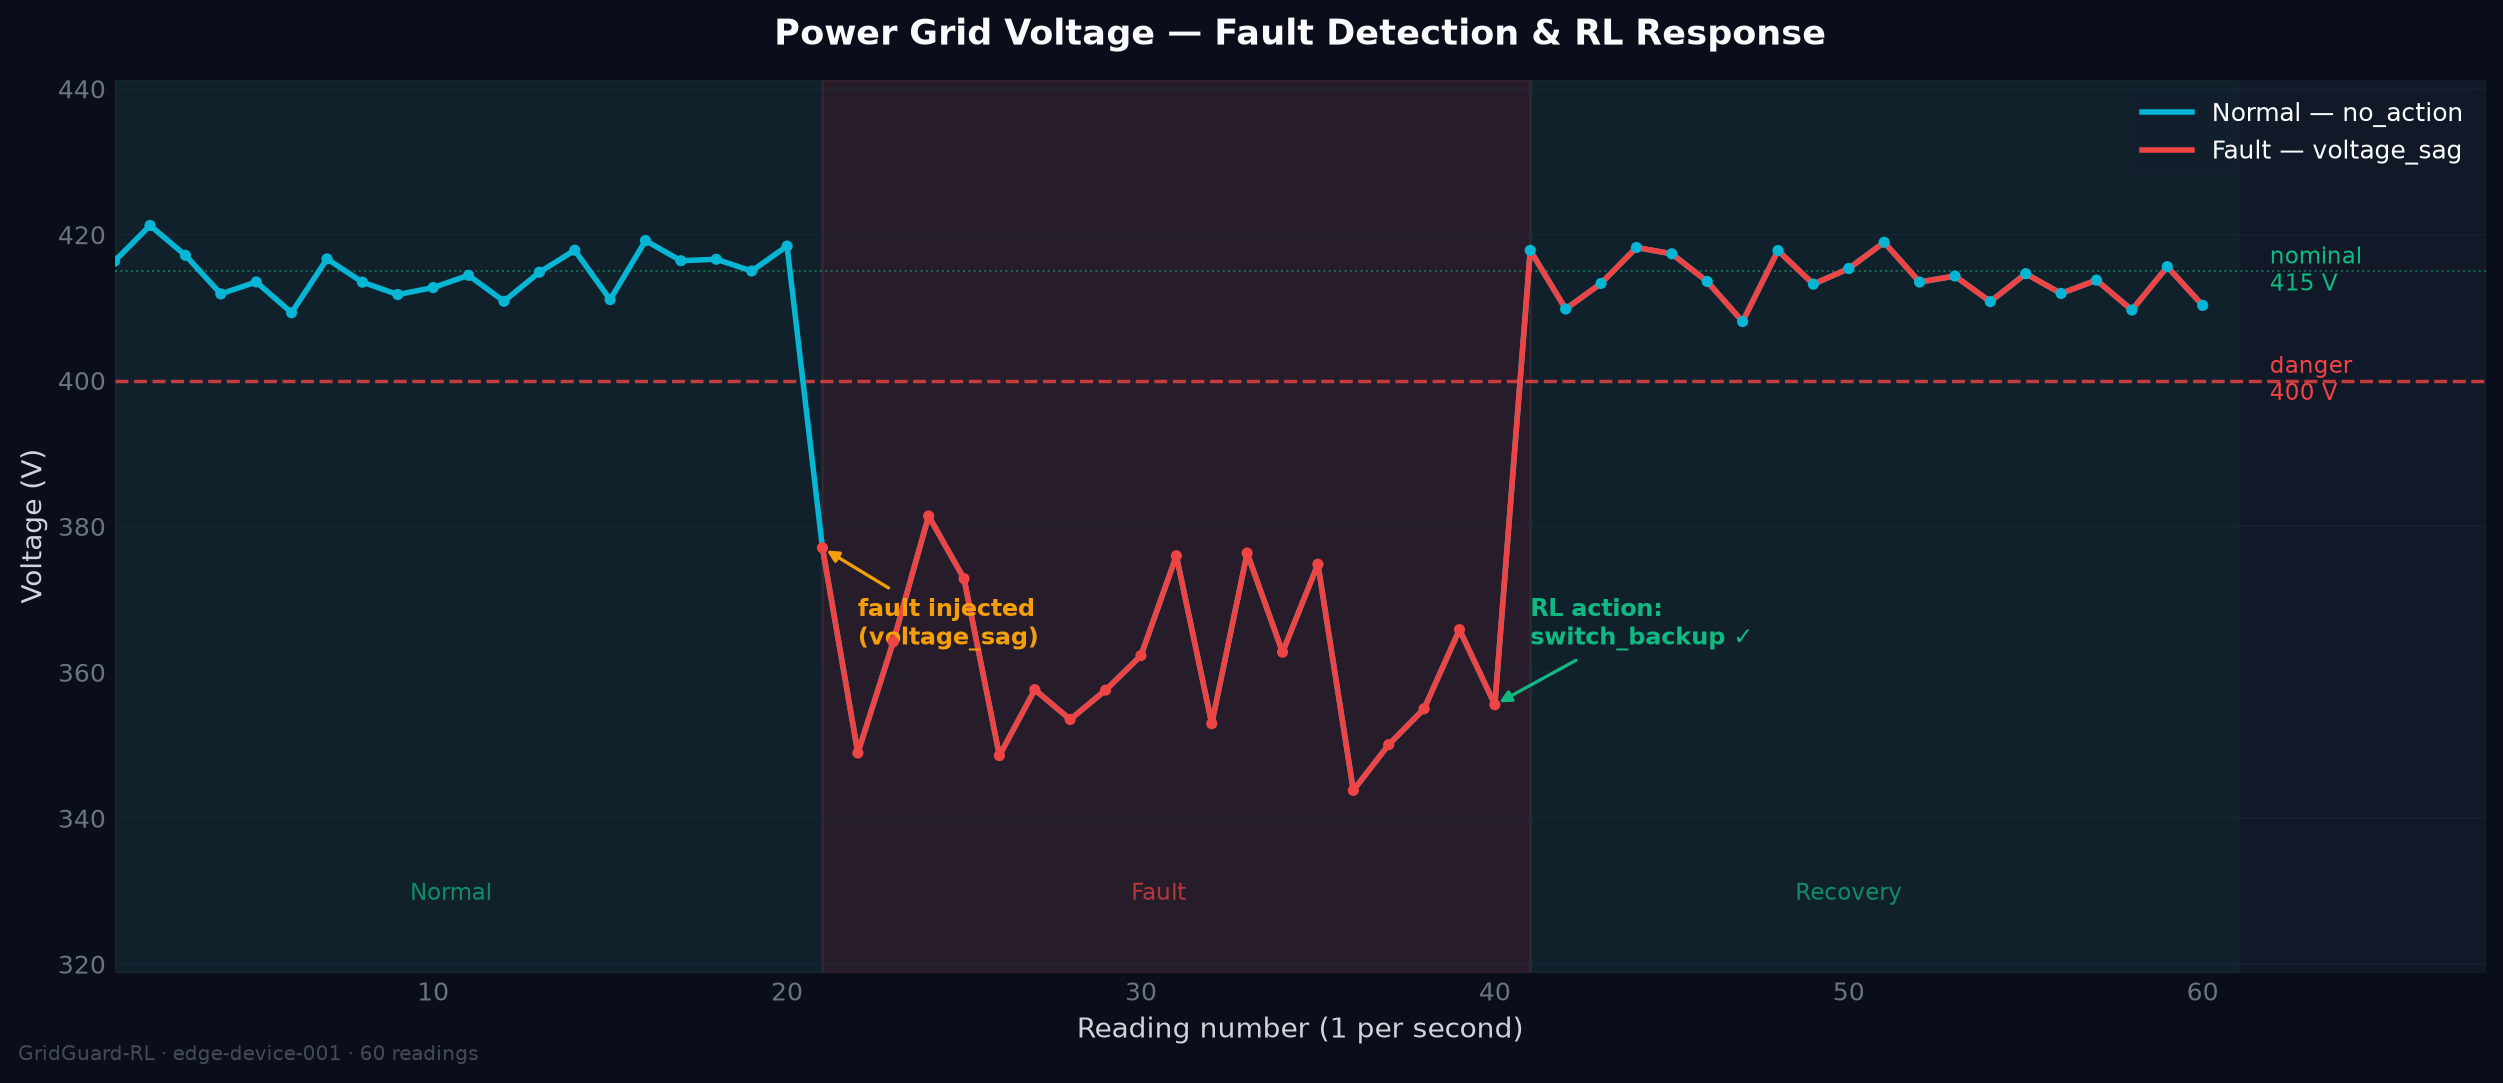

In [47]:
import json
import random
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# ── colors ────────────────────────────────────────────────────
BG    = "#0A0E1A"
CYAN  = "#06B6D4"
RED   = "#EF4444"
GREEN = "#10B981"
AMBER = "#F59E0B"
BLUE  = "#3B82F6"
GRAY  = "#6B7280"
WHITE = "#F9FAFB"

plt.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     "#111827",
    "axes.labelcolor":    "#D1D5DB",
    "axes.titlecolor":    WHITE,
    "xtick.color":        GRAY,
    "ytick.color":        GRAY,
    "grid.color":         "#1E2D42",
    "grid.linewidth":     0.6,
    "text.color":         WHITE,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
})

# ── load real data from demo_sag.json ─────────────────────────
candidate_paths = [
    Path("demo_sag.json"),
    Path("./data/demo_sag.json"),
    Path("../demo_sag.json"),
    Path("../data/demo_sag.json"),
    Path("../../demo_sag.json"),
    Path("../../data/demo_sag.json"),
    # demo_sag.json is generated by the edge simulator's --save flag, which
    # writes it into edge_simulator/local/ -- a sibling of this notebook's
    # folder, not a descendant, so the rglob() fallback below can never find
    # it there (rglob only searches downward from cwd). Check it explicitly.
    Path("../edge_simulator/local/demo_sag.json"),
    Path("../../edge_simulator/local/demo_sag.json"),
]

json_path = next((p for p in candidate_paths if p.exists()), None)

if json_path is None:
    search_root = Path.cwd().resolve()
    matches = list(search_root.rglob("demo_sag.json"))
    if matches:
        json_path = matches[0]

if json_path is None:
    raise FileNotFoundError(
        "demo_sag.json not found. Checked the notebook folder, parent folders, and recursive search."
    )

with open(json_path, "r", encoding="utf-8") as f:
    raw = json.load(f)

x        = list(range(1, len(raw) + 1))
voltages = [r["voltage_v"]  for r in raw]
states   = [r["grid_state"] for r in raw]

# find where fault starts and ends
fault_start = next((i+1 for i, s in enumerate(states) if s != "normal"), None)
fault_end   = next((i+1 for i in range(len(states)-1, -1, -1) if states[i] != "normal"), None)

# ── plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# background zones
if fault_start and fault_end:
    ax.axvspan(1,            fault_start, alpha=0.06, color=GREEN)
    ax.axvspan(fault_start,  fault_end+1, alpha=0.10, color=RED)
    ax.axvspan(fault_end+1,  x[-1]+1,    alpha=0.06, color=GREEN)

# reference lines
ax.axhline(400, color=RED,   linestyle="--", linewidth=1.4, alpha=0.8)
ax.axhline(415, color=GREEN, linestyle=":",  linewidth=0.8, alpha=0.5)
ax.text(x[-1]+1.5, 400, "  danger\n  400 V", color=RED,   fontsize=9, va="center")
ax.text(x[-1]+1.5, 415, "  nominal\n  415 V", color=GREEN, fontsize=9, va="center")

# split into normal and fault segments for coloring
norm_x, norm_y, fault_x, fault_y = [], [], [], []
for i, (xi, v, s) in enumerate(zip(x, voltages, states)):
    if s == "normal":
        norm_x.append(xi); norm_y.append(v)
        if fault_x:         # connect fault segment back to normal
            fault_x.append(xi); fault_y.append(v)
    else:
        fault_x.append(xi); fault_y.append(v)
        if norm_x:           # connect normal segment into fault
            norm_x.append(xi); norm_y.append(v)

ax.plot(norm_x,  norm_y,  color=CYAN, linewidth=2.2, label="Normal — no_action")
ax.plot(fault_x, fault_y, color=RED,  linewidth=2.2, label="Fault — voltage_sag")

# dots on each reading
for xi, v, s in zip(x, voltages, states):
    ax.scatter(xi, v, color=CYAN if s == "normal" else RED,
               s=20, zorder=5, edgecolors="none")

# fault injection arrow
if fault_start:
    ax.annotate("fault injected\n(voltage_sag)",
                xy=(fault_start, voltages[fault_start-1]),
                xytext=(fault_start + 1, min(voltages) + 20),
                color=AMBER, fontsize=9.5, fontweight="bold",
                arrowprops=dict(arrowstyle="-|>", color=AMBER, lw=1.3))

# RL response arrow
if fault_end:
    ax.annotate("RL action:\nswitch_backup ✓",
                xy=(fault_end, voltages[fault_end-1]),
                xytext=(fault_end + 1, min(voltages) + 20),
                color=GREEN, fontsize=9.5, fontweight="bold",
                arrowprops=dict(arrowstyle="-|>", color=GREEN, lw=1.3))

# zone labels at bottom
vmin = min(voltages) - 15
if fault_start:
    ax.text(fault_start / 2,              vmin, "Normal",   color=GREEN, fontsize=9, ha="center", alpha=0.7)
    ax.text((fault_start + fault_end)/2,  vmin, "Fault",    color=RED,   fontsize=9, ha="center", alpha=0.7)
    ax.text((fault_end + x[-1]) / 2,     vmin, "Recovery", color=GREEN, fontsize=9, ha="center", alpha=0.7)

ax.set_xlim(1, x[-1] + 8)
ax.set_ylim(min(voltages) - 25, max(voltages) + 20)
ax.set_xlabel("Reading number (1 per second)", fontsize=11)
ax.set_ylabel("Voltage (V)", fontsize=11)
ax.set_title("Power Grid Voltage — Fault Detection & RL Response",
             fontsize=14, fontweight="bold", pad=14)
ax.legend(loc="upper right", framealpha=0.15,
          facecolor="#111827", edgecolor="#1E2D42", fontsize=10)
ax.grid(True, axis="y", alpha=0.4)
ax.tick_params(length=0)
fig.text(0.01, 0.01,
         f"GridGuard-RL · {raw[0].get('device_id', 'edge-device')} · {len(raw)} readings",
         fontsize=8, color=GRAY, alpha=0.6)

plt.tight_layout()
plt.savefig("chart_voltage_timeline.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"Loaded {len(raw)} readings from demo_sag.json")
print(f"Fault start: reading {fault_start} | Fault end: reading {fault_end}")
print("Saved: chart_voltage_timeline.png")